In [1]:
import json
import os
from google.colab import userdata

try:
    # Busca as chaves no Secrets do Colab
    username = userdata.get("KAG_USER")
    key = userdata.get("KAG_KEY")

    # Configura o Kaggle
    dados_api = {"username": username, "key": key}
    os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
    caminho_json = os.path.expanduser("~/.kaggle/kaggle.json")
    with open(caminho_json, "w") as f:
        json.dump(dados_api, f)
    os.chmod(caminho_json, 0o600)
    print("Kaggle autenticado via Secrets")

    #Download do Dataset de carros e motos
    !kaggle datasets download utkarshsaxenadn/car-vs-bike-classification-dataset
    print("Dataset pronto para uso")

except Exception as e:
    print("Erro na autenticação")

Kaggle autenticado via Secrets
Dataset URL: https://www.kaggle.com/datasets/utkarshsaxenadn/car-vs-bike-classification-dataset
License(s): CC0-1.0
100% 103M/103M [00:01<00:00, 103MB/s] 

Dataset pronto para uso


In [2]:
!unzip -q car-vs-bike-classification-dataset.zip -d carro_vs_moto/

In [6]:
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

# Caminho único para a pasta raiz que contém as duas classes
DATA_DIR = "carro_vs_moto/Car-Bike-Dataset/"
IMG_HEIGHT = 180
IMG_WIDTH = 180
BATCH_SIZE = 32
EPOCHS = 20

#Carregamento do dataset de treino (80% dos dados)
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,  # Reserva 20% das imagens para validação
    subset="training",  # Define que este subconjunto é para treino
    seed=123,  # SEED idêntica em ambos para não misturar os dados
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode="binary",
)

#Carregamento do dataset de validação (20% dos dados)
val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,  # A mesma SEED garante que o corte seja feito no mesmo lugar
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode="binary",
)

#Nome das classes
class_names = train_ds.class_names
print(class_names)

#Otimização de performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 4000 files belonging to 2 classes.
Using 3200 files for training.
Found 4000 files belonging to 2 classes.
Using 800 files for validation.
['Bike', 'Car']


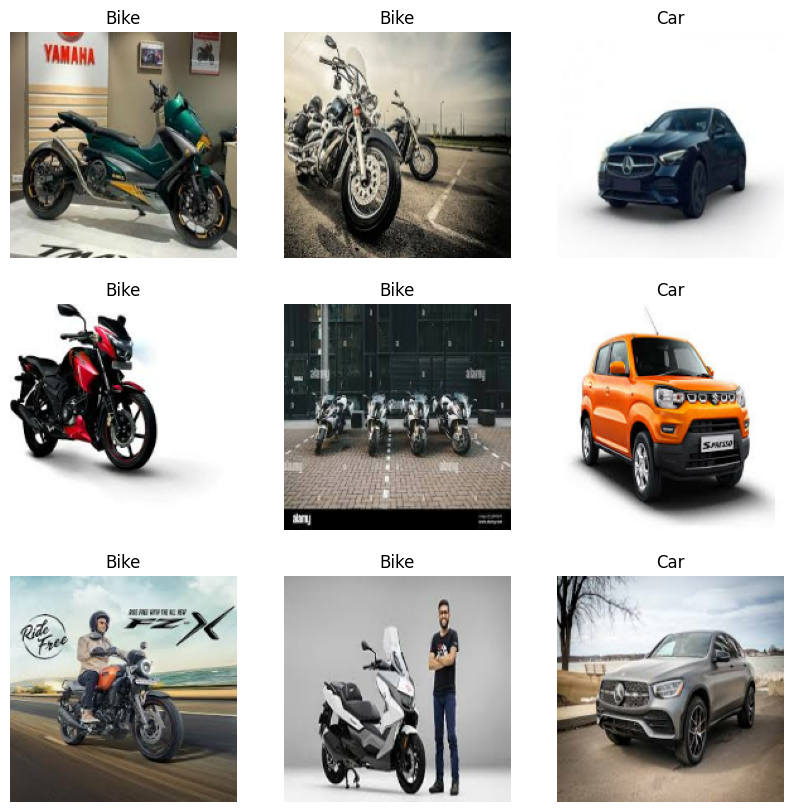

In [7]:
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[int(labels[i])])
        plt.axis("off")
plt.show()

In [8]:
for classe in os.listdir(DATA_DIR):
    caminho = os.path.join(DATA_DIR, classe)
    if os.path.isdir(caminho):
        print(f"{classe}: {len(os.listdir(caminho))} imagens")

Bike: 2000 imagens
Car: 2000 imagens


In [11]:
for images, labels in train_ds.take(1):
    print("Shape do batch:", images.shape)
    print("Shape dos labels:", labels.shape)

Shape do batch: (32, 180, 180, 3)
Shape dos labels: (32, 1)
